# Classification
Classification is a problem of predicting whether something is one thing or the other (there can be multiple things as the option, though).
Book version of the notebook – https://www.learnpytorch.io/02_pytorch_classification/
All other resources – https://github.com/DinoKiller0607/pytorch-deep-learning
In case you get stuck, refer – https://github.com/mrdbourke/pytorch-deep-learning/discussions

## Making classification data ready

In [1]:
from sklearn.datasets import make_circles

# Make aa 1000 samples
n_samples = 1000
# Create circles
X, y = make_circles(n_samples,
                    noise = 0.03,
                    random_state = 42)
len(X), len(y)

(1000, 1000)

In [2]:
# Print the data
print(f"First 5 samples of X are :\n{X[:5]}")
print(f"First 5 samples of y are :\n{y[:5]}")

First 5 samples of X are :
[[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 samples of y are :
[1 1 1 1 0]


In [3]:
# Make a Dataframe of circle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                        "X2": X[:, 1],
                        "label":y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


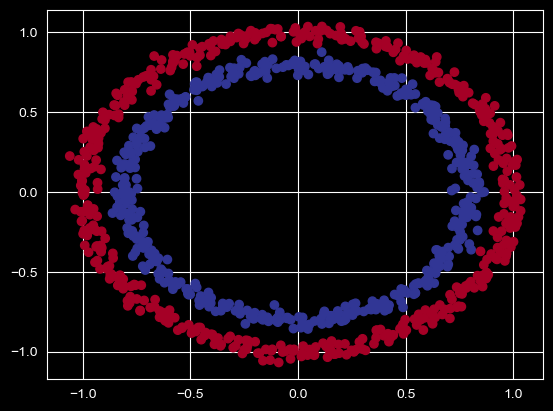

In [4]:
# Visualize, Visualize, Visualize
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
            y=X[:, 1],
            c=y,
            cmap=plt.cm.RdYlBu
            );

**Note:** The data we are working with is often referred to as a toy dataset, a dataset that is small enough to experiment but still sizeable enough to practice the fundamentals.

### Check input and output shapes

In [5]:
X.shape, y.shape

((1000, 2), (1000,))

In [6]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]], shape=(1000, 2))

In [7]:
# View the first example of features and labels
X_sample = X[0]
y_sample = y[0]
print(f"Values for one sample of X: {X_sample} and the same for y: {y_sample}")
print(f"Shapes for one sample of X: {X_sample.shape} and the same for y: {y_sample.shape}")

Values for one sample of X: [0.75424625 0.23148074] and the same for y: 1
Shapes for one sample of X: (2,) and the same for y: ()


### Turn data into tensors and create train and test splits

In [8]:
import torch
torch.__version__

'2.12.0+cu130'

In [9]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [10]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float32)
y = torch.from_numpy(y).type(torch.float32)

In [11]:
type(X), X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [12]:
# Split data into training and test sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size = 0.2, # 0.2 = 20% of data will be test set
                                                    random_state = 42)
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

## Building a model
Let's build a model to classify the blue and red points.
To do so, we want to:
1. Set up device-agnostic code, so our code will run on accelerator (GPU) if there is one.
2. Construct a model (by subclassing `nn.Module`)
3. Define a loss function and optimizer
4. Create a training and test loop

In [13]:
# PyTorch and nn
import torch
from torch import nn
# Make device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

Now we've set up device-agnostic code, let's create a model that:
1. Subclasses `nn.Module` (almost all models in PyTorch subclass `nn.Module`
2. Creates 2 `nn.Linear()` layers that are capable of handling the shapes of our data.
3. Defines a `forward()` method that outlines the forward pass (or forward computation) of the model.
4. Instantiate an instance of our model class and send it to our target `device`

In [14]:
# 1. Construct a model that subclasses nn.Module
class CircleModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling the shapes of our data
        self.layer1= nn.Linear(in_features= 2, out_features= 8) # Takes in 2 features and upscales to 8
        self.layer2= nn.Linear(in_features= 8, out_features= 1) # Takes in 8 features and downscales to 1
    # 3. Define a forward() method that outlines the forward pass
    def forward(self, x):
        return self.layer2(self.layer1(x))  # x -> layer1 -> layer2 -> output

# 4. Instantiate an instance of our model class and send it to the target device
model_0 = CircleModelV1().to(device)
model_0

CircleModelV1(
  (layer1): Linear(in_features=2, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=1, bias=True)
)

**Note**: The number of input features of the current layer MUST MATCH the number of output features of previous layer.
Otherwise, it will throw shape mismatch errors.

In [15]:
device

'cuda'

In [16]:
next(model_0.parameters()).device

device(type='cuda', index=0)

Let's replicate the model above using `nn.Sequential()`

In [17]:
model_1 = nn.Sequential(
    nn.Linear(in_features = 2, out_features= 8),
    nn.Linear(in_features = 8, out_features= 1)
).to(device)
model_1, next(model_1.parameters()).device

(Sequential(
   (0): Linear(in_features=2, out_features=8, bias=True)
   (1): Linear(in_features=8, out_features=1, bias=True)
 ),
 device(type='cuda', index=0))

`nn.Sequential()` is an easier way to create neural networks. However, if you want full control over the architecture, subclassing `nn.Module()` is a better way.

In [18]:
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.4763,  0.2869],
                      [-0.2750,  0.1167],
                      [ 0.6329, -0.6958],
                      [-0.0482, -0.1181],
                      [ 0.3711,  0.2719],
                      [-0.0155, -0.1339],
                      [-0.3588,  0.6225],
                      [-0.5548, -0.4530]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.0412,  0.1766,  0.0470,  0.4892,  0.4829, -0.1356,  0.3312,  0.3272],
                     device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.0013,  0.0357, -0.1795,  0.2004, -0.1479, -0.2383,  0.1103,  0.1305]],
                     device='cuda:0')),
             ('layer2.bias', tensor([0.0636], device='cuda:0'))])

In [19]:
# Make predictions
with torch.inference_mode():
    untrained_preds = model_0(X_test.to(device))
print(f"Length of untrained predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(X_test)}, Shape: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labels:\n{y_test[:10]}")

Length of untrained predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200, 2])

First 10 predictions:
tensor([[ 0.3832],
        [ 0.2972],
        [ 0.3740],
        [ 0.3868],
        [ 0.0017],
        [-0.0480],
        [ 0.0050],
        [-0.0767],
        [ 0.3898],
        [ 0.2873]], device='cuda:0')

First 10 labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [20]:
X_test[:10], y_test[:10]

(tensor([[-0.3752,  0.6827],
         [ 0.0154,  0.9600],
         [-0.7028, -0.3147],
         [-0.2853,  0.9664],
         [ 0.4024, -0.7438],
         [ 0.6323, -0.5711],
         [ 0.8561,  0.5499],
         [ 1.0034,  0.1903],
         [-0.7489, -0.2951],
         [ 0.0538,  0.9739]]),
 tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.]))

### Set up loss function and optimizer
Which loss function or optimizer should you use?
Again... this is problem-specific.
For example, for a regression problem you might want MAE or MSE (mean absolute error or mean squared error).
For a classification problem, you might want binary cross-entropy or categorical cross-entropy (or simply, cross-entropy).
As a reminder, the loss function measures how wrong your predictions are.
And for optimizers, two of the most common and useful are — SGD, and Adam optimizer.
However, there are several built-in options in PyTorch.
* For some common choices of loss functions and optimizers — https://www.learnpytorch.io/02_pytorch_classification/#21-setup-loss-function-and-optimizer
* For the loss function we're going to use `torch.nn.BCEWithLogitsLoss()`, for more on what binary cross entropy (BCE) is, check out this article — https://towardsdatascience.com/understanding-binary-cross-entropy-log-loss-a-visual-explanation-a3ac6025181a
* For a definition on what a logit is in deep learning — https://stackoverflow.com/a/52111173/7900723
* For different optimizers see `torch.optim`.

In [21]:
# Set up a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = BCE with sigmoid activation built-in
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr= 0.1)
model_0.state_dict()

OrderedDict([('layer1.weight',
              tensor([[-0.4763,  0.2869],
                      [-0.2750,  0.1167],
                      [ 0.6329, -0.6958],
                      [-0.0482, -0.1181],
                      [ 0.3711,  0.2719],
                      [-0.0155, -0.1339],
                      [-0.3588,  0.6225],
                      [-0.5548, -0.4530]], device='cuda:0')),
             ('layer1.bias',
              tensor([-0.0412,  0.1766,  0.0470,  0.4892,  0.4829, -0.1356,  0.3312,  0.3272],
                     device='cuda:0')),
             ('layer2.weight',
              tensor([[-0.0013,  0.0357, -0.1795,  0.2004, -0.1479, -0.2383,  0.1103,  0.1305]],
                     device='cuda:0')),
             ('layer2.bias', tensor([0.0636], device='cuda:0'))])

In [23]:
# Calculate accuracy — out of 100 examples, what percentage does our model get right?
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, torch.round(y_pred)).sum().item()
    acc = (correct / len(y_true)) * 100
    return acc